# MODULO4 -- TAE EN INTELIGENCIA ARTIFCIAL

    *PROFESOR*: DR GERMAN PINEDO
    *STUDENT*: CESAR EDUARDO INDA CENICEROS

# **Convolución para MNIST-1D**

Este cuaderno explora una red convolucional 1D para MNIST-1D.

Ejecuta las celdas en orden. En varios lugares verás la palabra "TAREA": sigue esas instrucciones, anticipa qué ocurrirá o escribe el código necesario para completar las funciones.


In [1]:
# Ejecuta esta celda una vez si necesitas instalar el repositorio MNIST-1D
!pip install git+https://github.com/greydanus/mnist1d

  Cloning https://github.com/greydanus/mnist1d to C:\Users\tiori\AppData\Local\Temp\pip-req-build-v2f9xr60
  Resolved https://github.com/greydanus/mnist1d to commit 7878d96082abd200c546a07a4101fa90b30fdf7e
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/greydanus/mnist1d 'C:\Users\tiori\AppData\Local\Temp\pip-req-build-v2f9xr60'


In [2]:
import numpy as np
import os
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
import mnist1d
import random

In [3]:
args = mnist1d.data.get_dataset_args()

dataset_path = "./mnist1d_data.pkl"

data = mnist1d.data.get_dataset(
    args,
    path=dataset_path,
    download=not os.path.exists(dataset_path),
    regenerate=False
)

print("Samples in training set: {}".format(len(data["y"])))
print("Samples in test set: {}".format(len(data["y_test"])))
print("Length of each sample: {}".format(data["x"].shape[-1]))

Successfully loaded data from ./mnist1d_data.pkl
Samples in training set: 4000
Samples in test set: 1000
Length of each sample: 40


In [4]:
# Carga los datos
train_data_x = data['x'].transpose()
train_data_y = data['y']
val_data_x = data['x_test'].transpose()
val_data_y = data['y_test']
# Muestra los tamaños
print("Training data: %d samples (columns), each with %d dimensions (rows)"%((train_data_x.shape[1],train_data_x.shape[0])))
print("Validation data: %d samples (columns), each with %d dimensions (rows)"%((val_data_x.shape[1],val_data_x.shape[0])))

Training data: 4000 samples (columns), each with 40 dimensions (rows)
Validation data: 1000 samples (columns), each with 40 dimensions (rows)


Define la red

In [5]:
# Estos datos tienen 40 dimensiones de entrada y 10 dimensiones de salida
# Las entradas corresponden a los 40 desplazamientos de la plantilla MNIST-1D.
D_i = 40
# Las salidas corresponden a los 10 dígitos
D_o = 10


# TAREA: crea un modelo con las siguientes capas
# 1. Capa convolucional (entrada: longitud 40 y 1 canal; kernel 3; paso 2; padding="valid"; 15 canales de salida)
# 2. ReLU
# 3. Capa convolucional (entrada: longitud 19 y 15 canales; kernel 3; paso 2; padding="valid"; 15 canales de salida)
# 4. ReLU
# 5. Capa convolucional (entrada: longitud 9 y 15 canales; kernel 3; paso 2; padding="valid"; 15 canales de salida)
# 6. ReLU
# 7. Aplanamiento (convierte 4x15) a longitud 60
# 8. Capa lineal (tamaño de entrada = 60, tamaño de salida = 10)
# Documentación útil:
# https://pytorch.org/docs/1.13/generated/torch.nn.Conv1d.html?highlight=conv1d#torch.nn.Conv1d
# https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html
# https://pytorch.org/docs/1.13/generated/torch.nn.Linear.html?highlight=linear#torch.nn.Linear

# TEN EN CUENTA QUE LAS CAPAS CONVOLUCIONALES NECESITAN RECIBIR EL NÚMERO DE CANALES DE ENTRADA COMO PARÁMETRO
# Y NO EL TAMAÑO DE LA ENTRADA.

model = nn.Sequential(
  nn.Conv1d(1, 15, kernel_size=3, stride=2, padding="valid"),
  nn.ReLU(),
  nn.Conv1d(15, 15, kernel_size=3, stride=2, padding="valid"),
  nn.ReLU(),
  nn.Conv1d(15, 15, kernel_size=3, stride=2, padding="valid"),
  nn.ReLU(),
  nn.Flatten(),
  nn.Linear(60, 10))

In [6]:
# Inicialización de pesos de He
def weights_init(layer):
    if isinstance(layer, (nn.Conv1d, nn.Linear)):
        nn.init.kaiming_uniform_(
            layer.weight,
            mode="fan_in",
            nonlinearity="relu"
        )

        if layer.bias is not None:
            nn.init.zeros_(layer.bias)

Usando dispositivo: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Epoch   1/100, training loss 2.033058, training error  77.12%, validation loss 2.051494, validation error  77.40%, lr 0.050000
Epoch   2/100, training loss 1.564320, training error  61.77%, validation loss 1.595403, validation error  62.60%, lr 0.050000
Epoch   3/100, training loss 1.302621, training error  52.02%, validation loss 1.321719, validation error  53.60%, lr 0.050000
Epoch   4/100, training loss 1.099738, training error  42.90%, validation loss 1.139836, validation error  44.90%, lr 0.050000
Epoch   5/100, training loss 0.932905, training error  35.57%, validation loss 0.959486, validation error  36.70%, lr 0.050000
Epoch   6/100, training loss 0.820845, training error  32.15%, validation loss 0.853300, validation error  32.20%, lr 0.050000
Epoch   7/100, training loss 0.706904, training error  26.72%, validation loss 0.751677, validation error  29.30%, lr 0.050000
Epoch   8/100, training loss 0.578020, trainin

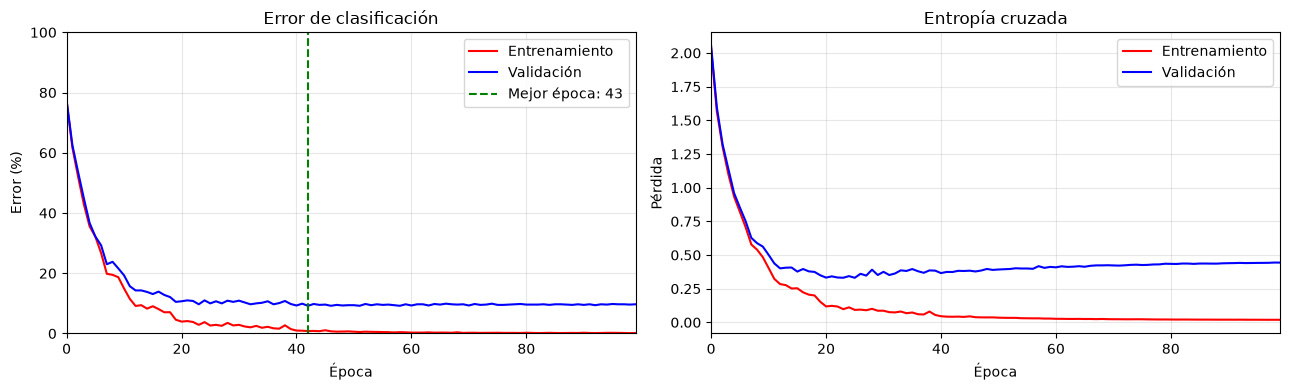

In [7]:
# ============================================================
# Configuración y entrenamiento
# ============================================================

SEED = 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Detecta GPU CUDA, GPU MPS o CPU
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if (
        hasattr(torch.backends, "mps")
        and torch.backends.mps.is_available()
    )
    else "cpu"
)

print(f"Usando dispositivo: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Inicializa los pesos antes de crear el optimizador
model.apply(weights_init)

# Mueve el modelo al dispositivo
model = model.to(device)

# Función de pérdida
loss_function = nn.CrossEntropyLoss()

# El optimizador debe construirse después de mover el modelo
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.05,
    momentum=0.9
)

# Reduce la tasa de aprendizaje a la mitad cada 20 épocas
scheduler = StepLR(
    optimizer,
    step_size=20,
    gamma=0.5
)

# ------------------------------------------------------------
# Conversión de los datos a tensores
# ------------------------------------------------------------

x_train = torch.tensor(
    train_data_x.transpose(),
    dtype=torch.float32
)

y_train = torch.tensor(
    train_data_y,
    dtype=torch.long
)

x_val = torch.tensor(
    val_data_x.transpose(),
    dtype=torch.float32
)

y_val = torch.tensor(
    val_data_y,
    dtype=torch.long
)

# Los datos del DataLoader permanecen en CPU.
# Cada lote se mueve a la GPU durante el entrenamiento.
generator = torch.Generator()
generator.manual_seed(SEED)

data_loader = DataLoader(
    TensorDataset(x_train, y_train),
    batch_size=100,
    shuffle=True,
    num_workers=0,
    generator=generator
)

# Copias completas para calcular las estadísticas
x_train_eval = x_train.to(device)
y_train_eval = y_train.to(device)
x_val_eval = x_val.to(device)
y_val_eval = y_val.to(device)

# ------------------------------------------------------------
# Arreglos para almacenar resultados
# ------------------------------------------------------------

n_epoch = 100

losses_train = np.zeros(n_epoch)
errors_train = np.zeros(n_epoch)
losses_val = np.zeros(n_epoch)
errors_val = np.zeros(n_epoch)
learning_rates = np.zeros(n_epoch)

# ------------------------------------------------------------
# Entrenamiento
# ------------------------------------------------------------

for epoch in range(n_epoch):

    model.train()

    for x_batch, y_batch in data_loader:

        # Mueve el lote al dispositivo
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Agrega la dimensión correspondiente al canal:
        # (batch, 40) -> (batch, 1, 40)
        x_batch = x_batch.unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        # Paso hacia adelante
        pred = model(x_batch)

        # Calcula pérdida
        loss = loss_function(pred, y_batch)

        # Retropropagación
        loss.backward()

        # Actualización de parámetros
        optimizer.step()

    # --------------------------------------------------------
    # Evaluación
    # --------------------------------------------------------

    model.eval()

    with torch.inference_mode():

        pred_train = model(x_train_eval.unsqueeze(1))
        pred_val = model(x_val_eval.unsqueeze(1))

        predicted_train_class = pred_train.argmax(dim=1)
        predicted_val_class = pred_val.argmax(dim=1)

        train_accuracy = (
            predicted_train_class == y_train_eval
        ).float().mean()

        val_accuracy = (
            predicted_val_class == y_val_eval
        ).float().mean()

        errors_train[epoch] = (
            100.0 * (1.0 - train_accuracy)
        ).item()

        errors_val[epoch] = (
            100.0 * (1.0 - val_accuracy)
        ).item()

        losses_train[epoch] = loss_function(
            pred_train,
            y_train_eval
        ).item()

        losses_val[epoch] = loss_function(
            pred_val,
            y_val_eval
        ).item()

    learning_rates[epoch] = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:3d}/{n_epoch}, "
        f"training loss {losses_train[epoch]:.6f}, "
        f"training error {errors_train[epoch]:6.2f}%, "
        f"validation loss {losses_val[epoch]:.6f}, "
        f"validation error {errors_val[epoch]:6.2f}%, "
        f"lr {learning_rates[epoch]:.6f}"
    )

    scheduler.step()

# ============================================================
# Resultados finales
# ============================================================

best_epoch = np.argmin(errors_val)

print("\nResultados finales")
print("-" * 50)
print(f"Mejor época: {best_epoch + 1}")
print(
    f"Mejor exactitud de validación: "
    f"{100.0 - errors_val[best_epoch]:.2f}%"
)
print(
    f"Error final de entrenamiento: "
    f"{errors_train[-1]:.2f}%"
)
print(
    f"Error final de validación: "
    f"{errors_val[-1]:.2f}%"
)

# ------------------------------------------------------------
# Gráficas
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(
    errors_train,
    color="red",
    label="Entrenamiento"
)

axes[0].plot(
    errors_val,
    color="blue",
    label="Validación"
)

axes[0].axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Mejor época: {best_epoch + 1}"
)

axes[0].set_xlim(0, n_epoch - 1)
axes[0].set_ylim(0, 100)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Error (%)")
axes[0].set_title("Error de clasificación")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    losses_train,
    color="red",
    label="Entrenamiento"
)

axes[1].plot(
    losses_val,
    color="blue",
    label="Validación"
)

axes[1].set_xlim(0, n_epoch - 1)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
axes[1].set_title("Entropía cruzada")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()